<a href="https://colab.research.google.com/github/ingridjimene/An-lisis-de-Tuberculosis-con-Python/blob/main/Caso_An%C3%A1lisis_de_Tuberculosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de tuberculosis

 **Cargar los datos**

In [ ]:
# Paquetes par amanipular datos
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [ ]:
#Paquetes para conectarse a Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Csv population
pop = pd.read_csv('/content/drive/MyDrive/A/population.csv')
pop.head()

,country,year,population
0,Afghanistan,1995,17586073
1,Afghanistan,1996,18415307
2,Afghanistan,1997,19021226
3,Afghanistan,1998,19496836
4,Afghanistan,1999,19987071


In [ ]:
#Csv who
who = pd.read_csv('/content/drive/MyDrive/A/who.csv')
who.head()

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
who.head(100)

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AF,AFG,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,AF,AFG,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AF,AFG,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AF,AFG,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,AF,AFG,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**¿Qué es la tuberculosis?**

La tuberculosis (TB) es una enfermedad infecciosa potencialmente grave que afecta principalmente a los pulmones, pero que también puede afectar otras partes del cuerpo, como los riñones, la columna vertebral y el cerebro. Es causada por una bacteria llamada Mycobacterium tuberculosis.

**Métodos de diagnóstico**

**Para Tuberculosis Latente (TBL):**

- **Prueba cutánea de la tuberculina (PPD o prueba de Mantoux):** Se inyecta una pequeña cantidad de derivado proteico purificado (PPD) debajo de la piel del antebrazo. Después de 48 a 72 horas, un profesional de la salud evalúa la reacción en el sitio de la inyección. Una reacción positiva indica exposición a la bacteria, pero no distingue entre infección latente y enfermedad activa.
- **Pruebas de liberación de interferón gamma (IGRA):** Son análisis de sangre que miden la respuesta inmunitaria a las bacterias de la tuberculosis. Ejemplos incluyen QuantiFERON-TB Gold Plus y T-SPOT.TB. Estas pruebas son más específicas que la PPD y menos propensas a dar falsos positivos por vacunación BCG previa.

**Para Tuberculosis Activa:**

- **Examen de esputo (baciloscopia y cultivo):** Se recogen muestras de esputo (moco que se expulsa al toser) para examinarlas al microscopio y buscar la presencia de bacilos tuberculosos (baciloscopia). También se realiza un cultivo para hacer crecer las bacterias en un laboratorio, lo que permite identificar la especie y realizar pruebas de sensibilidad a los medicamentos.
- **Radiografía de tórax:** Revela anomalías en los pulmones que son características de la tuberculosis, como infiltrados, cavidades o derrames pleurales. Es una herramienta clave para diagnosticar la TB pulmonar.
- **Pruebas moleculares rápidas (por ejemplo, GeneXpert MTB/RIF):** Son pruebas rápidas que detectan el ADN de Mycobacterium tuberculosis y la resistencia a la rifampicina (un medicamento clave) en horas. Son muy útiles en áreas con alta carga de TB.
- **Biopsia:** Si la TB afecta otros órganos (TB extrapulmonar), se puede tomar una biopsia del tejido afectado para su análisis histopatológico y microbiológico.
- **Análisis de líquidos corporales:** En casos de TB que afectan otros sitios, como la pleura (TB pleural), las meninges (meningitis tuberculosa) o los ganglios linfáticos, se pueden analizar los líquidos de esas áreas.
- **Tomografía computarizada (TC) o resonancia magnética (RM):** Pueden usarse para obtener imágenes más detalladas de los órganos afectados, especialmente en casos de TB extrapulmonar.

#Limpieza y manipulación de datos

**Explorar los valores nulos/faltantes/NA**

In [ ]:
#Cuántos valores faltantes hay por columna?
who.isna().sum()


,0
country,0
iso2,34
iso3,0
year,0
new_sp_m014,4067
new_sp_m1524,4031
new_sp_m2534,4034
new_sp_m3544,4021
new_sp_m4554,4017
new_sp_m5564,4022


In [ ]:
#Explorar los valores faltantes en la columna iso2
who[who.iso2.isna()]

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
4369,Namibia,NaN,NAM,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4370,Namibia,NaN,NAM,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4371,Namibia,NaN,NAM,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4372,Namibia,NaN,NAM,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4373,Namibia,NaN,NAM,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4374,Namibia,NaN,NAM,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4375,Namibia,NaN,NAM,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4376,Namibia,NaN,NAM,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4377,Namibia,NaN,NAM,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4378,Namibia,NaN,NAM,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Los valores NA se debe a que el iso2 de Namibia es "NA", y pandas lo tomo como un valor faltante
who.loc[who.country == 'Namibia', 'iso2'] = 'NA'

In [ ]:
#Las demás columnas de casos con valores faltantes van a tener un valor default de 0
who.fillna(0, inplace=True)

In [ ]:
#Cuantos valores faltantes hay por columna en la tabla de pop?
pop.isna().sum()

,0
country,0
year,0
population,0


In [ ]:
who2 = who.melt(id_vars=['country', 'iso2', 'iso3', 'year'])
who2.head(100)

,country,iso2,iso3,year,variable,value
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0


In [ ]:
#Crear una columna que contenga el género (masculino o femenino)
#Crear una función de Python que contenga las reglas
def asignar_genero(valor):
  if "m" in valor:
    return "masculino"
  else:
    return "femenino"


In [ ]:
who2["genero"] = who2["variable"].apply(asignar_genero)
who2.head(15)

,country,iso2,iso3,year,variable,value,genero
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,masculino
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,masculino
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,masculino
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,masculino
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,masculino
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0,masculino
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0,masculino
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0,masculino
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0,masculino
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0,masculino


In [ ]:
def asignar_metodo(valor):
  if"rel"in valor:
    return"relapse"
  elif "sn" in valor:
    return"negative pulmonary snear"
  elif "sp" in valor:
    return"positive pulmonary snear"
  elif "ep" in valor:
    return "extrapulmonary"
  else:
    return "to define"

In [ ]:
who2["metodo"] = who2["variable"].apply(asignar_metodo)
who2.head()

,country,iso2,iso3,year,variable,value,genero,metodo
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,masculino,positive pulmonary snear
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,masculino,positive pulmonary snear
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,masculino,positive pulmonary snear
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,masculino,positive pulmonary snear
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,masculino,positive pulmonary snear


In [ ]:
# age group (014 = 0-14 yrs of age, 1524 = 15-24, 2534 = 25-34, 3544 = 35-44 years of age, 4554 = 45-54, 5564 = 55-64, 65 = 65 years or older).
def asignar_grupoedad(valor):
  if "014" in valor:
    return "0-14"
  elif "1524" in valor:
    return "15-24"
  elif "2534" in valor:
    return "25-34"
  elif "3544" in valor:
    return "35-44"
  elif "4554" in valor:
    return "45-54"
  elif "5564" in valor:
    return "55-64"
  else:
    return "65+"

In [ ]:
who2["grupoedad"] = who2["variable"].apply(asignar_grupoedad)
who2.head()

,country,iso2,iso3,year,variable,value,genero,metodo,grupoedad
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,masculino,positive pulmonary snear,0-14
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,masculino,positive pulmonary snear,0-14
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,masculino,positive pulmonary snear,0-14
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,masculino,positive pulmonary snear,0-14
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,masculino,positive pulmonary snear,0-14


In [ ]:
#remover la columna variable
who2.drop(columns=["variable"], inplace=True)

In [ ]:
#renombrar la columna value a casos
who2.rename(columns={"value":"casos"}, inplace=True)

In [ ]:
who2.head()

,country,iso2,iso3,year,casos,genero,metodo,grupoedad
0,Afghanistan,AF,AFG,1980,0.0,masculino,positive pulmonary snear,0-14
1,Afghanistan,AF,AFG,1981,0.0,masculino,positive pulmonary snear,0-14
2,Afghanistan,AF,AFG,1982,0.0,masculino,positive pulmonary snear,0-14
3,Afghanistan,AF,AFG,1983,0.0,masculino,positive pulmonary snear,0-14
4,Afghanistan,AF,AFG,1984,0.0,masculino,positive pulmonary snear,0-14


In [ ]:
#Traer el dato de la población total
# Traer el dato de la poblacion total
df = pd.merge(who2, pop, on=["country", "year"], how="inner")
df.head(10)

,country,iso2,iso3,year,casos,genero,metodo,grupoedad,population
0,Afghanistan,AF,AFG,1995,0.0,masculino,positive pulmonary snear,0-14,17586073
1,Afghanistan,AF,AFG,1996,0.0,masculino,positive pulmonary snear,0-14,18415307
2,Afghanistan,AF,AFG,1997,0.0,masculino,positive pulmonary snear,0-14,19021226
3,Afghanistan,AF,AFG,1998,30.0,masculino,positive pulmonary snear,0-14,19496836
4,Afghanistan,AF,AFG,1999,8.0,masculino,positive pulmonary snear,0-14,19987071
5,Afghanistan,AF,AFG,2000,52.0,masculino,positive pulmonary snear,0-14,20595360
6,Afghanistan,AF,AFG,2001,129.0,masculino,positive pulmonary snear,0-14,21347782
7,Afghanistan,AF,AFG,2002,90.0,masculino,positive pulmonary snear,0-14,22202806
8,Afghanistan,AF,AFG,2003,127.0,masculino,positive pulmonary snear,0-14,23116142
9,Afghanistan,AF,AFG,2004,139.0,masculino,positive pulmonary snear,0-14,24018682


In [ ]:
#Cómo guardar la tabla "df" como un archivo csv
df.to_csv("tuberculosis.csv") #se guarda en la carpeta de la sesión
df.to_csv("/content/drive/MyDrive/A/tuberculosis.csv") #se guarda en la carpeta de Google Drive

In [ ]:
import matplotlib.pyplot as plt # base de visualizacion en Python
import seaborn as sns # visualizaciones mas sencillas hechas sobre Matplotlib
import plotly.express as px # visualizaciones interactivas

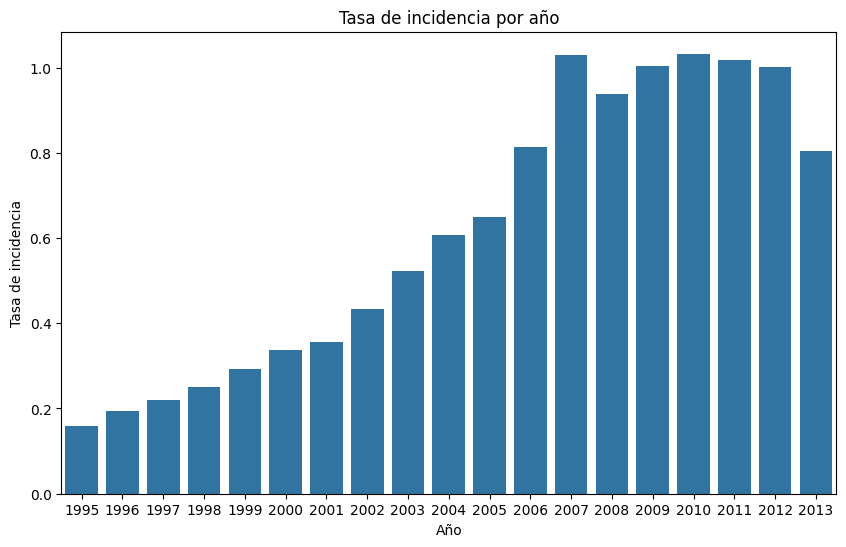

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la tabla by_year para la visualización
by_year = df.groupby('year').agg(
    total_casos=('casos', 'sum'),
    total_population=('population', 'sum')
).reset_index()

by_year['tasa_incidencia'] = (by_year['total_casos'] / by_year['total_population']) * 100000 # Tasa por 100,000 habitantes

# Crear nuestra primera visualizacion con seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x="year", y="tasa_incidencia", data=by_year)
plt.title("Tasa de incidencia por año")
plt.xlabel("Año")
plt.ylabel("Tasa de incidencia")
# guardar la grafica en nuestro drive
plt.savefig("/content/drive/MyDrive/A/grafica_incidencia.png")

In [ ]:
# grafica de barras con plotly
fig = px.bar(by_year, x="year", y="tasa_incidencia")
fig.show()